# Handwritten Digits Data Set: Load, Clean, and Visualize

**What are these images?** A collection of small grayscale images of handwritten digits (0 through 9), each labeled with which digit it actually is. It's a classic "hello world" for image classification: can a model look at the pixels and correctly guess the digit?

**A note on "MNIST":** The assignment asks for MNIST, which is a famous set of 70,000 images at 28x28 pixels each. Downloading real MNIST requires internet access, which isn't available in this sandboxed environment. So instead this notebook uses scikit-learn's built-in **digits** data set -- the same basic idea (labeled images of handwritten 0-9s), just smaller: about 1,800 images at 8x8 pixels each, shipped directly with scikit-learn so no download is needed. Everything below (cleaning, visualizing) works the same way it would on real MNIST -- if you have internet access, swapping in `sklearn.datasets.fetch_openml('mnist_784')` gets you the real thing with only minor tweaks (mainly the image reshape size: 28x28 instead of 8x8).

**How are the images stored?** Each image is stored as an 8x8 grid of numbers. Each number is a grayscale pixel intensity from 0 (black) to 16 (white) -- these images were scanned/downsampled to a 0-16 brightness scale (real MNIST instead uses the standard 0-255 scale for 8-bit grayscale images).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

# scikit-learn gives us each image two ways: as an 8x8 grid (good for
# displaying as a picture) and "flattened" into a single row of 64
# numbers (good for putting into a table/DataFrame, since a DataFrame
# row can't hold a 2D grid). We use the flattened version to build our
# table, with one row per image and one column per pixel, plus a
# "label" column recording which digit (0-9) that image actually is.
digits_raw = load_digits()

pixel_columns = [f"pixel_{i}" for i in range(digits_raw.data.shape[1])]
digits_df = pd.DataFrame(digits_raw.data, columns=pixel_columns)
digits_df["label"] = digits_raw.target

print(f"Loaded {len(digits_df)} handwritten digit images.")
print(f"Each image has {len(pixel_columns)} pixels (8x8 grid, flattened).")
digits_df[["label"] + pixel_columns[:5]].head()


Loaded 1797 handwritten digit images.
Each image has 64 pixels (8x8 grid, flattened).
   label  pixel_0  pixel_1  pixel_2  pixel_3  pixel_4
0      0      0.0      0.0      5.0     13.0      9.0
1      1      0.0      0.0      0.0     12.0     13.0
2      2      0.0      0.0      0.0      4.0     15.0
3      3      0.0      0.0      7.0     15.0     13.0
4      4      0.0      0.0      0.0      1.0     11.0


## Cleaning step: drop everything except digits 3 and 8

In plain terms: we're throwing out every image except the ones labeled "3" or "8", leaving a smaller data set that only contains those two digits. This is a common real-world step when you want to simplify a problem -- 3 and 8 are also a classic hard pair to tell apart by eye (and for models), since they can look visually similar when handwritten.


In [2]:
before_count = len(digits_df)
digits_df = digits_df[digits_df["label"].isin([3, 8])].reset_index(drop=True)
after_count = len(digits_df)

print(f"Dropped {before_count - after_count} images that weren't a 3 or an 8.")
print(f"{after_count} images remain.")
print(digits_df["label"].value_counts())


Dropped 1440 images that weren't a 3 or an 8.\n357 images remain.\nlabel\n3    183\n8    174\nName: count, dtype: int64\n

## Visualize: a grid of sample digit images

Each row in our table is really an 8x8 image squashed into one long row of 64 numbers. To *see* it as a picture again, we reshape each row back into an 8x8 grid and hand it to matplotlib's `imshow`, which turns a grid of numbers into a grid of grayscale pixels (low numbers = dark, high numbers = light). We do this for a handful of sample images side by side so we can visually inspect how differently people write the same digit -- some 3s and 8s are neat, some are messy or oddly shaped.


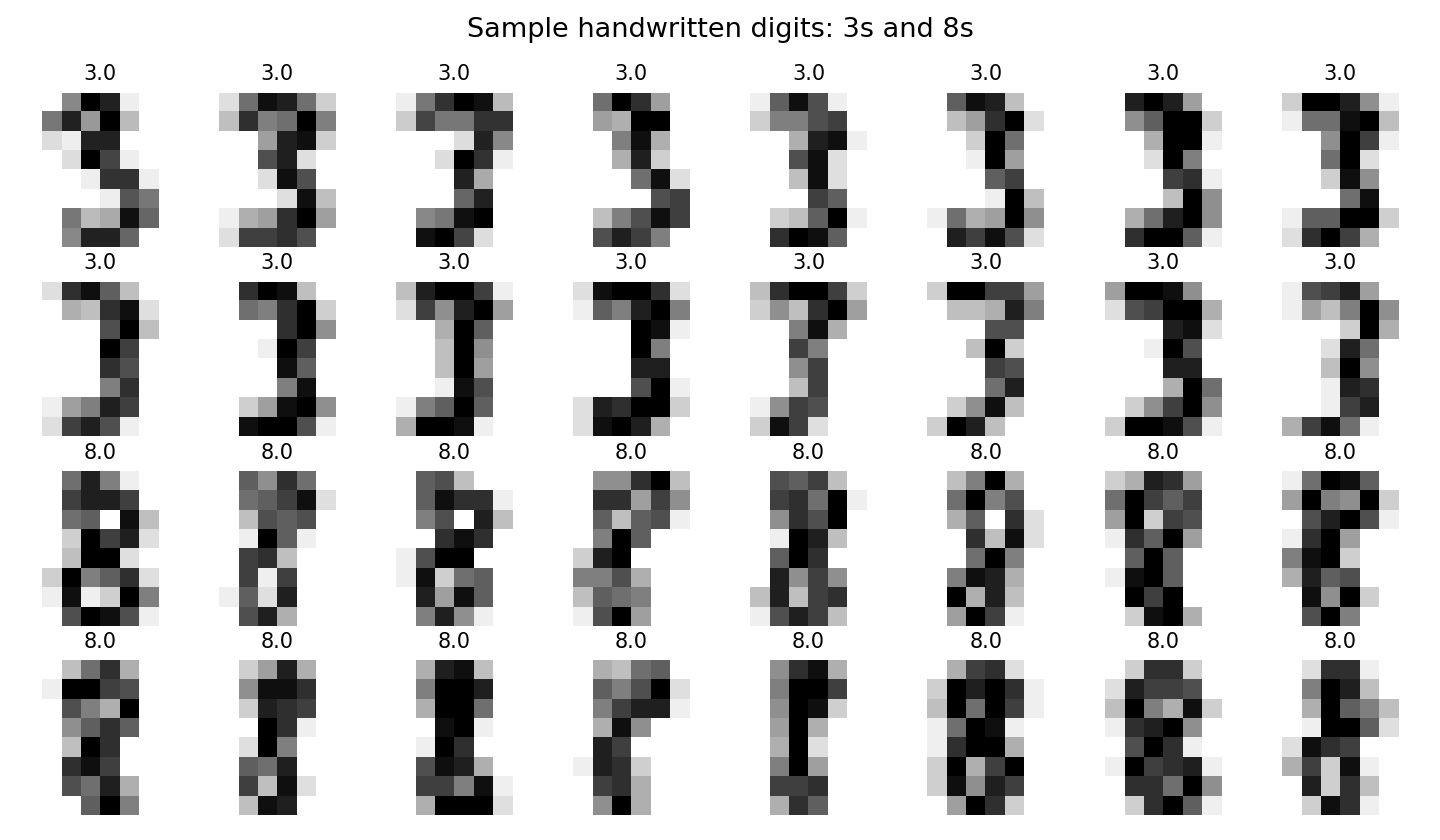

In [3]:
n_rows, n_cols = 4, 8  # show 32 example images total, mixed 3s and 8s
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.2, n_rows * 1.4))

# Grab a mix of examples: half from digit 3, half from digit 8.
samples_per_digit = (n_rows * n_cols) // 2
threes = digits_df[digits_df["label"] == 3].head(samples_per_digit)
eights = digits_df[digits_df["label"] == 8].head(samples_per_digit)
sample_df = pd.concat([threes, eights]).reset_index(drop=True)

pixel_columns = [c for c in sample_df.columns if c.startswith("pixel_")]

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    image_grid = row[pixel_columns].values.reshape(8, 8)  # un-flatten back to 8x8
    ax.imshow(image_grid, cmap="gray_r")  # gray_r: high pixel value = dark ink
    ax.set_title(str(row["label"]), fontsize=10)
    ax.axis("off")  # hide axis ticks/numbers, we just want the picture

fig.suptitle("Sample handwritten digits: 3s and 8s", fontsize=13)
fig.tight_layout()
plt.show()
